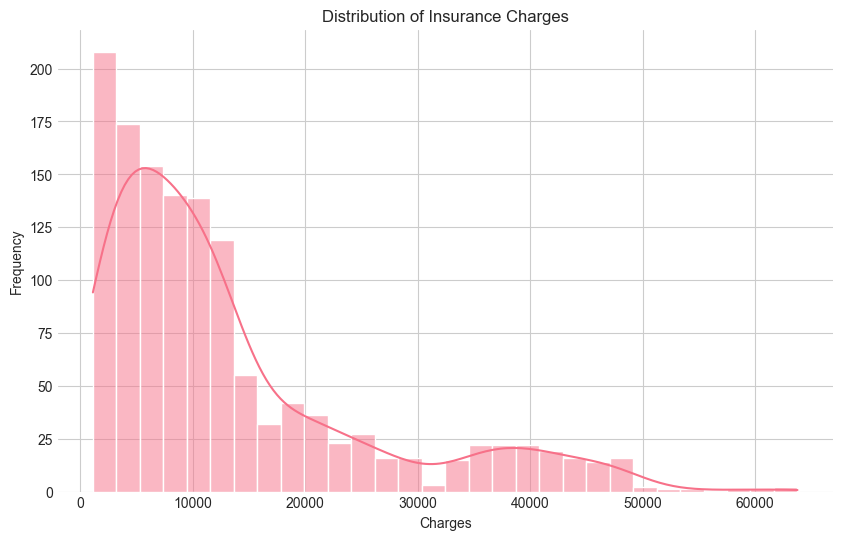

In [211]:
sns.histplot(df['charges'], kde=True, bins=30)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

In [212]:
print("Skewness of charges:", df['charges'].skew())

Skewness of charges: 1.5158796580240388


In [213]:
# Log-transform if highly skewed
df['log_charges'] = np.log1p(df['charges'])

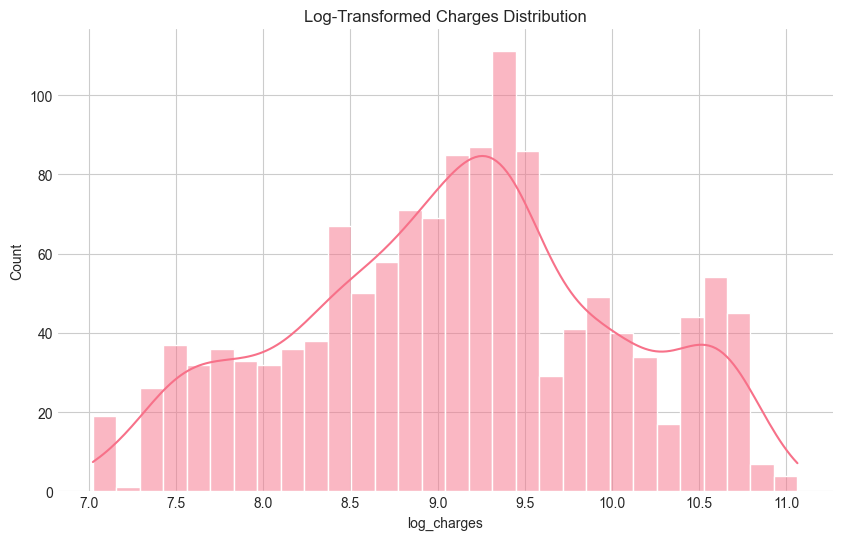

In [214]:
sns.histplot(df['log_charges'], kde=True, bins=30)
plt.title("Log-Transformed Charges Distribution")
plt.show()

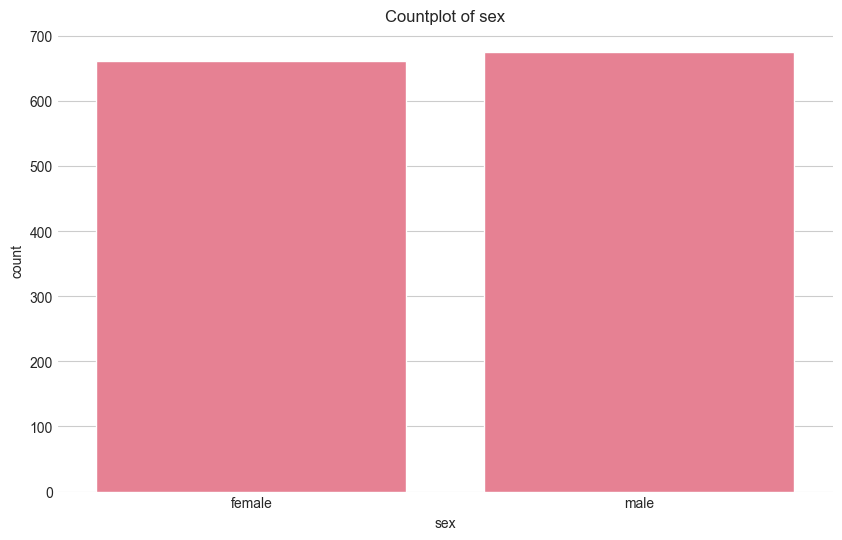

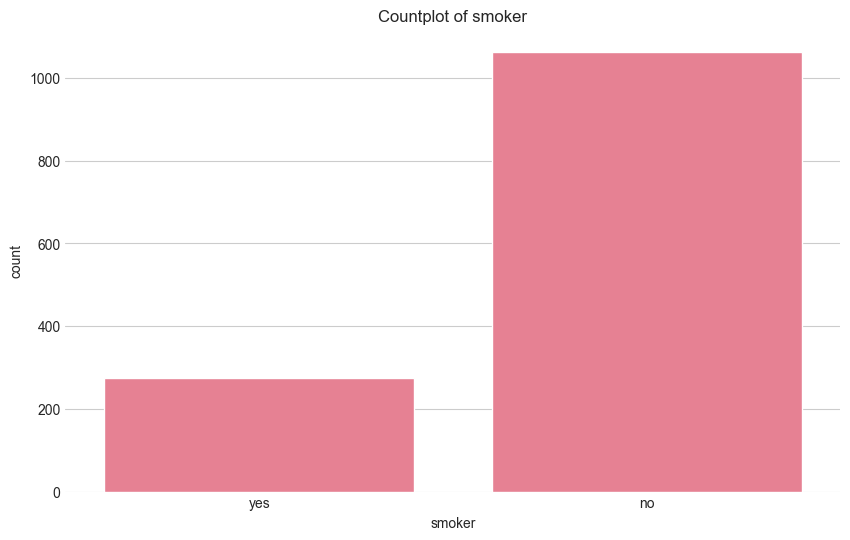

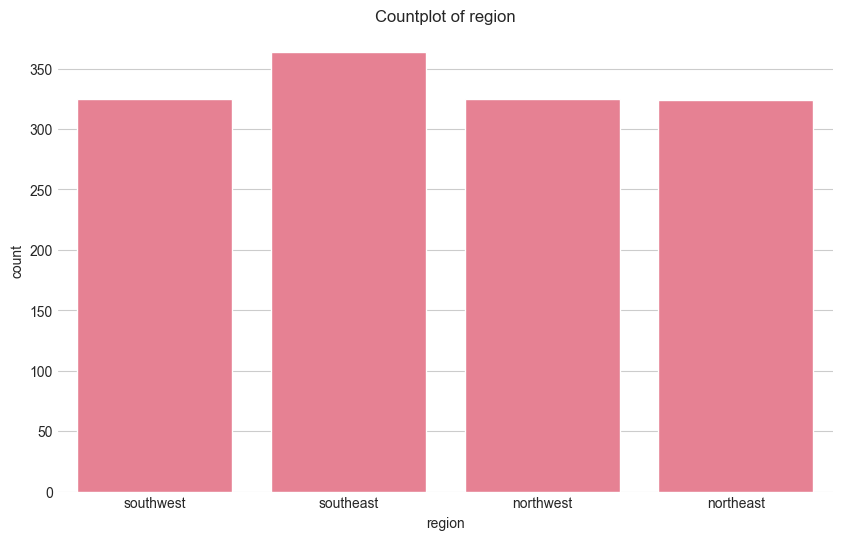

In [215]:
categorical_features = ['sex', 'smoker', 'region']
for col in categorical_features:
    sns.countplot(data=df, x=col)
    plt.title(f"Countplot of {col}")
    plt.show()

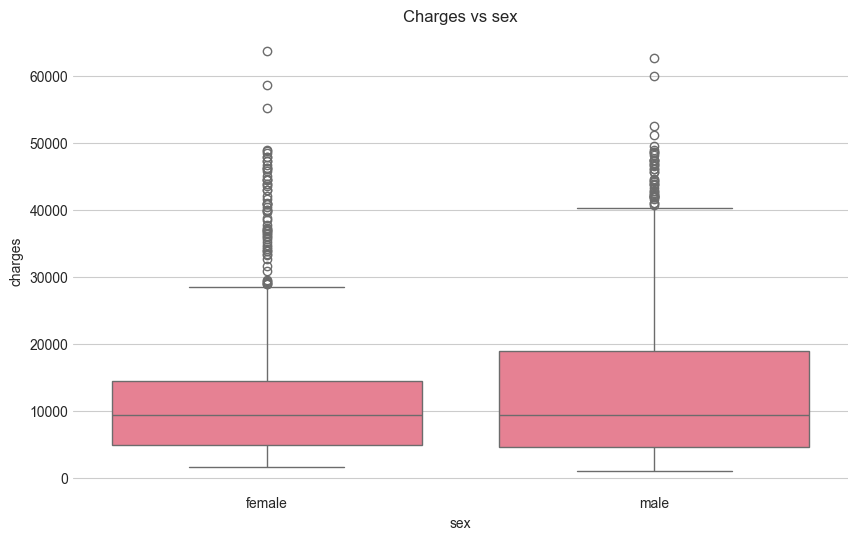

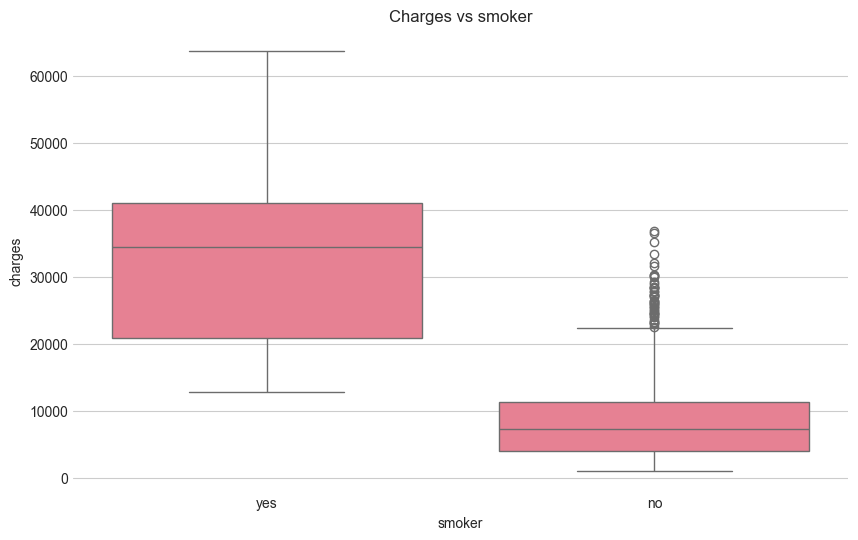

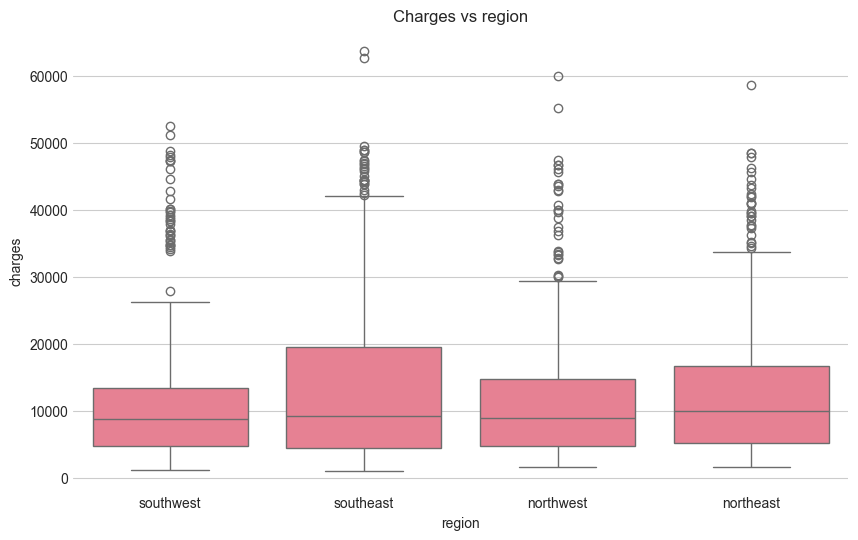

In [216]:
for col in categorical_features:
    sns.boxplot(data=df, x=col, y='charges')
    plt.title(f"Charges vs {col}")
    plt.show()

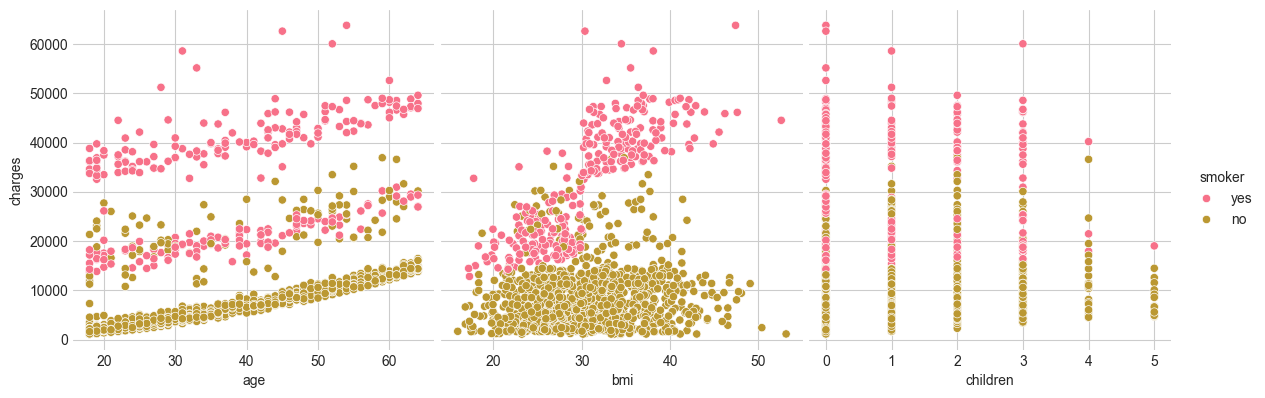

In [217]:
numerical_features = ['age', 'bmi', 'children']
sns.pairplot(df, x_vars=numerical_features, y_vars='charges', hue='smoker', height=4)
plt.show()

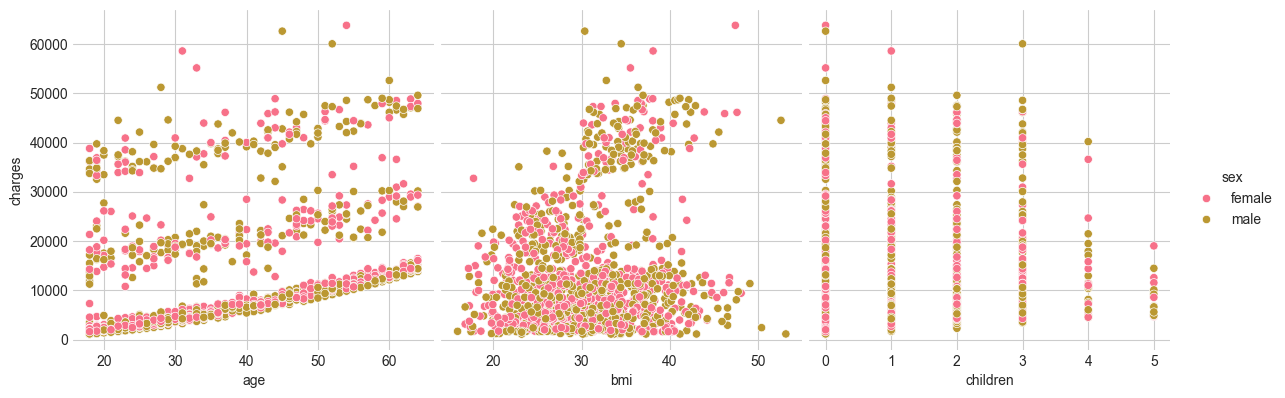

In [218]:
numerical_features = ['age', 'bmi', 'children']
sns.pairplot(df, x_vars=numerical_features, y_vars='charges', hue='sex', height=4)
plt.show()

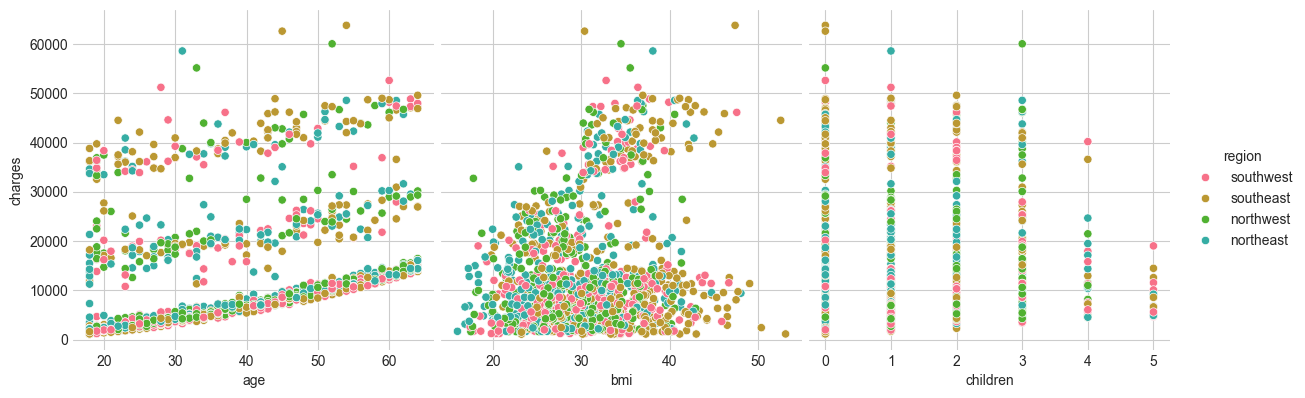

In [219]:
numerical_features = ['age', 'bmi', 'children']
sns.pairplot(df, x_vars=numerical_features, y_vars='charges', hue='region', height=4)
plt.show()

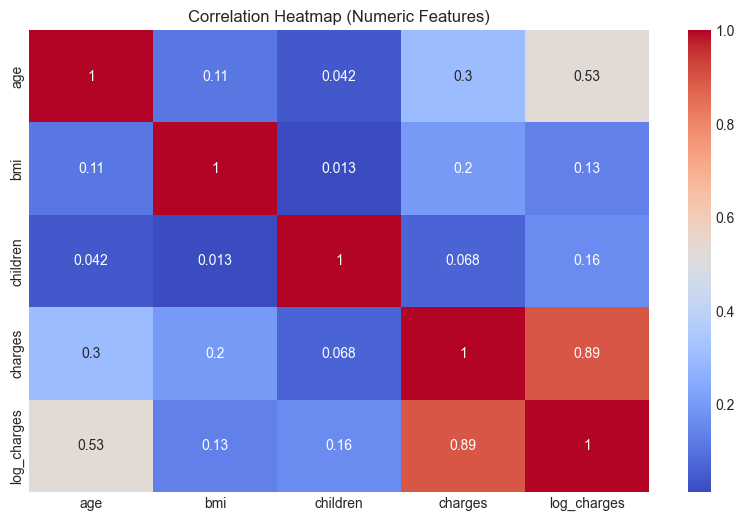

In [220]:
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [221]:
df['bmi_category'] = pd.cut(df['bmi'], bins=[0,18.5,25,30,100], labels=['Underweight','Normal','Overweight','Obese'])
df.head()

,age,sex,bmi,children,smoker,region,charges,log_charges,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,9.734236,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,7.453882,Obese
2,28,male,33.000,3,no,southeast,4449.46200,8.400763,Obese
3,33,male,22.705,0,no,northwest,21984.47061,9.998137,Normal
4,32,male,28.880,0,no,northwest,3866.85520,8.260455,Overweight


In [222]:
df.head()

,age,sex,bmi,children,smoker,region,charges,log_charges,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,9.734236,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,7.453882,Obese
2,28,male,33.000,3,no,southeast,4449.46200,8.400763,Obese
3,33,male,22.705,0,no,northwest,21984.47061,9.998137,Normal
4,32,male,28.880,0,no,northwest,3866.85520,8.260455,Overweight


In [223]:
df['sex'] = df['sex'].map({'male':0, 'female':1})
df['smoker'] = df['smoker'].map({'no':0, 'yes':1})

In [224]:
df = pd.get_dummies(df, columns=['region'], drop_first=False)

In [225]:
df = pd.get_dummies(df, columns=['bmi_category'], drop_first=False)
df.head()

,age,sex,bmi,children,smoker,charges,log_charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,9.734236,False,False,False,True,False,False,True,False
1,18,0,33.770,1,0,1725.55230,7.453882,False,False,True,False,False,False,False,True
2,28,0,33.000,3,0,4449.46200,8.400763,False,False,True,False,False,False,False,True
3,33,0,22.705,0,0,21984.47061,9.998137,False,True,False,False,False,True,False,False
4,32,0,28.880,0,0,3866.85520,8.260455,False,True,False,False,False,False,True,False


In [226]:
df = df.drop(columns=["bmi"])


In [227]:
df.head()

,age,sex,children,smoker,charges,log_charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,0,1,16884.92400,9.734236,False,False,False,True,False,False,True,False
1,18,0,1,0,1725.55230,7.453882,False,False,True,False,False,False,False,True
2,28,0,3,0,4449.46200,8.400763,False,False,True,False,False,False,False,True
3,33,0,0,0,21984.47061,9.998137,False,True,False,False,False,True,False,False
4,32,0,0,0,3866.85520,8.260455,False,True,False,False,False,False,True,False


In [228]:
X= df.drop(columns=['charges','log_charges'])
Y=df["charges"]
Y_log=df["log_charges"]

In [229]:
x_train,x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2,random_state=42)

In [230]:
lr1 = LinearRegression()
lr1.fit(x_train, y_train)

y_pred = lr1.predict(x_test)

print("R^2 score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R^2 score: 0.7787003551804961
RMSE: 5861.440875570444


In [231]:
residuals = y_test - y_pred

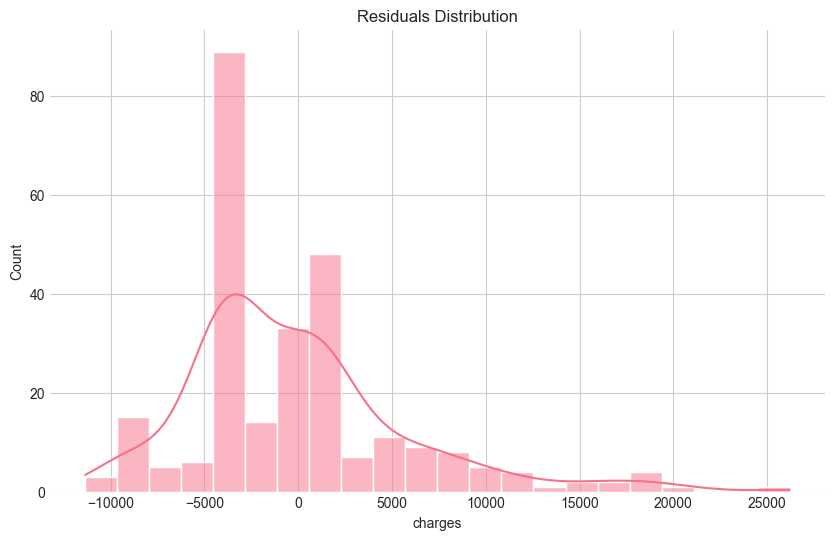

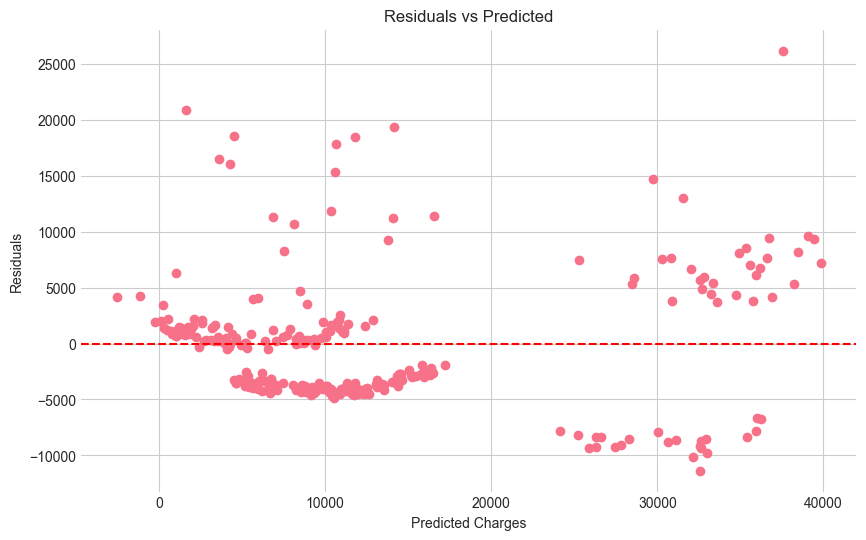

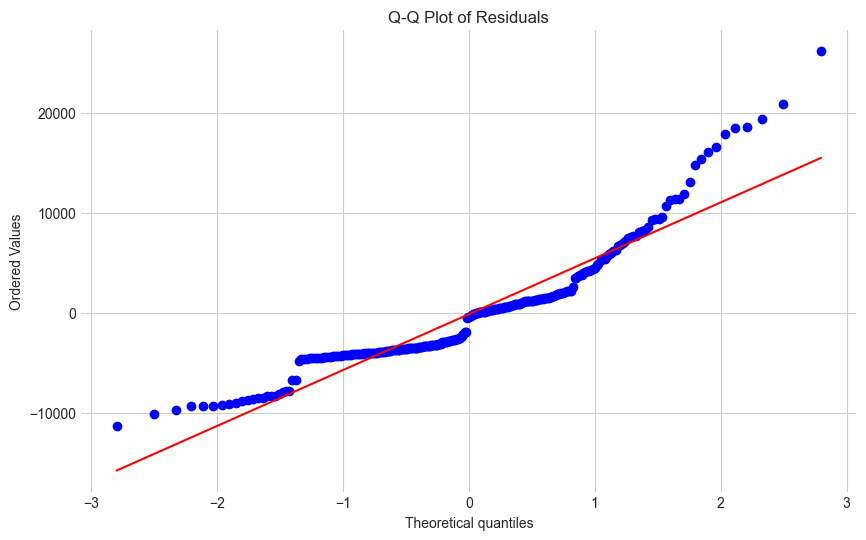

In [232]:
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

# Residual vs predicted
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# Q-Q plot for normality
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()


                     Feature   Coefficient
3                     smoker  23646.936272
11        bmi_category_Obese   4029.611199
8   bmi_category_Underweight  -3338.020694
9        bmi_category_Normal   -700.922571
4           region_northeast    416.494216
2                   children    416.382822
7           region_southwest   -383.587098
0                        age    256.977014
5           region_northwest    -63.064877
6           region_southeast     30.157760
1                        sex     18.431933
10   bmi_category_Overweight      9.332065


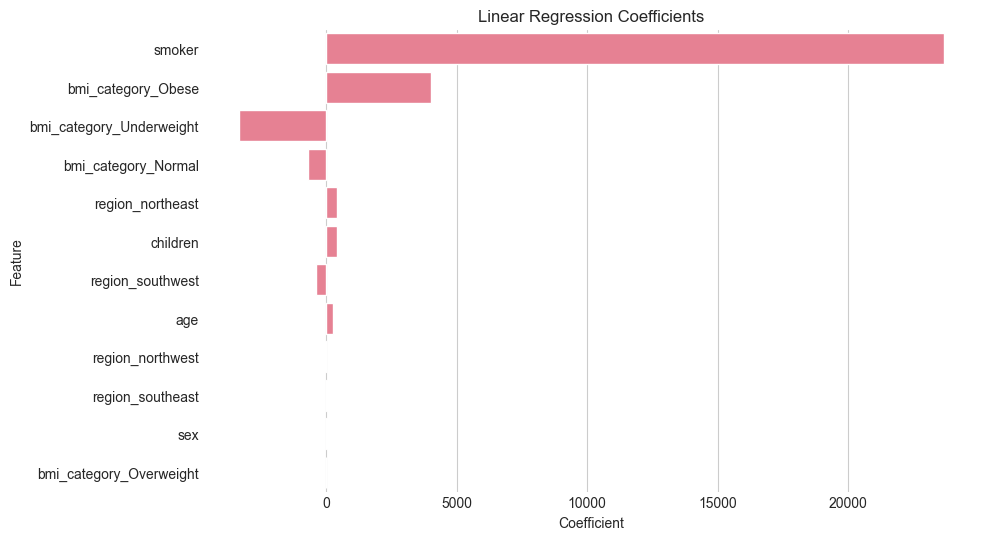

In [233]:

coefficients = pd.DataFrame({'Feature': x_train.columns, 'Coefficient': lr1.coef_})
coefficients = coefficients.sort_values(by='Coefficient', key=abs, ascending=False)
print(coefficients)

sns.barplot(data=coefficients, x='Coefficient', y='Feature')
plt.title("Linear Regression Coefficients")
plt.show()


In [234]:
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)
ridge_pred = ridge.predict(x_test)
print("Ridge R^2:", r2_score(y_test, ridge_pred))

lasso = Lasso(alpha=0.1)
lasso.fit(x_train, y_train)
lasso_pred = lasso.predict(x_test)
print("Lasso R^2:", r2_score(y_test, lasso_pred))

Ridge R^2: 0.7787163512685484
Lasso R^2: 0.7787087327533879


In [235]:
x_train,x_test, y_log_train, y_log_test = train_test_split(X,Y_log, test_size=0.2,random_state=42)

In [236]:
lr = LinearRegression()
lr.fit(x_train, y_log_train)

y_log_pred = lr.predict(x_test)

print("R^2 score:", r2_score(y_log_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_log_test, y_pred)))

R^2 score: -318840688.7130558
RMSE: 16928.998158851082


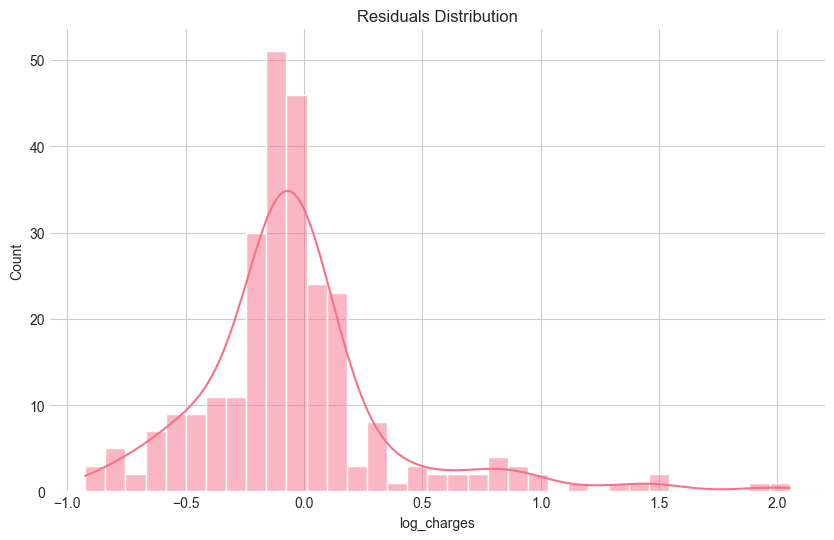

In [237]:
residuals = y_log_test - y_log_pred

# Residual histogram
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

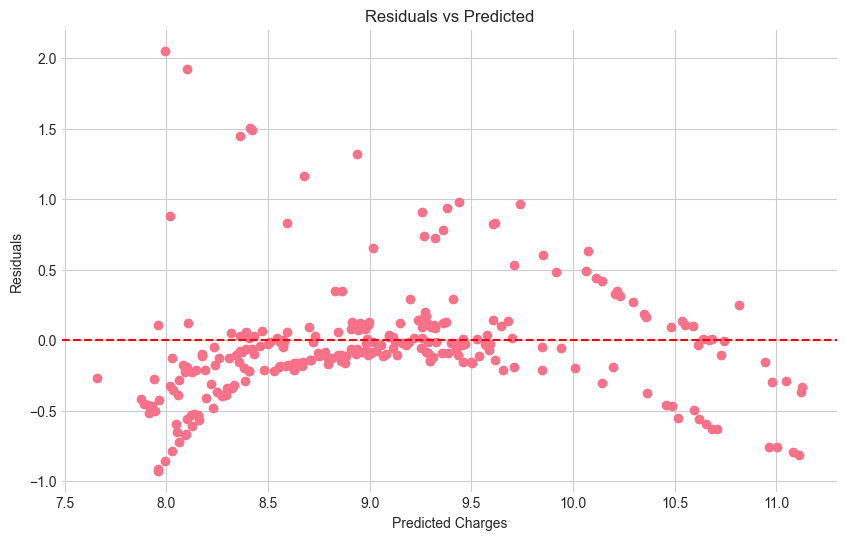

In [238]:
# Residual vs predicted
plt.scatter(y_log_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()


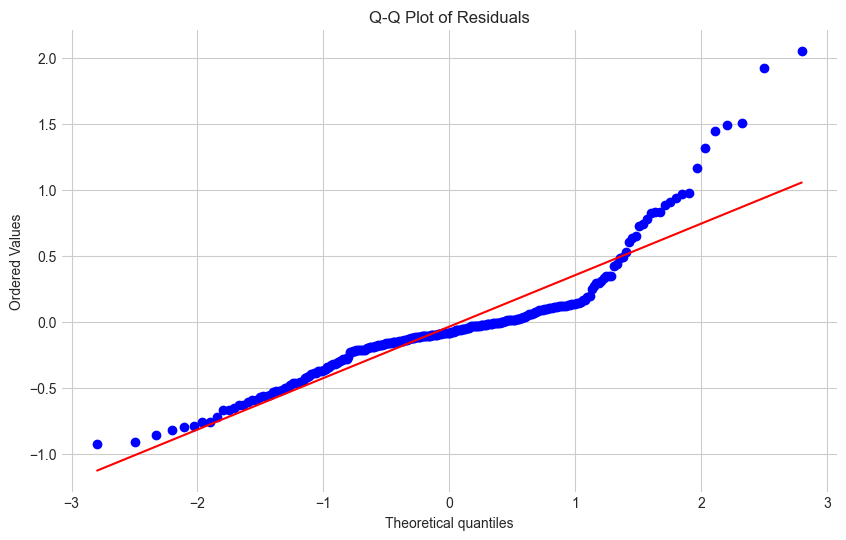

In [239]:
# Q-Q plot for normality
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

                     Feature  Coefficient
3                     smoker     1.552530
8   bmi_category_Underweight    -0.213893
11        bmi_category_Obese     0.181014
2                   children     0.092494
4           region_northeast     0.077814
1                        sex     0.074122
6           region_southeast    -0.047899
7           region_southwest    -0.044951
10   bmi_category_Overweight     0.042876
0                        age     0.034184
5           region_northwest     0.015037
9        bmi_category_Normal    -0.009997


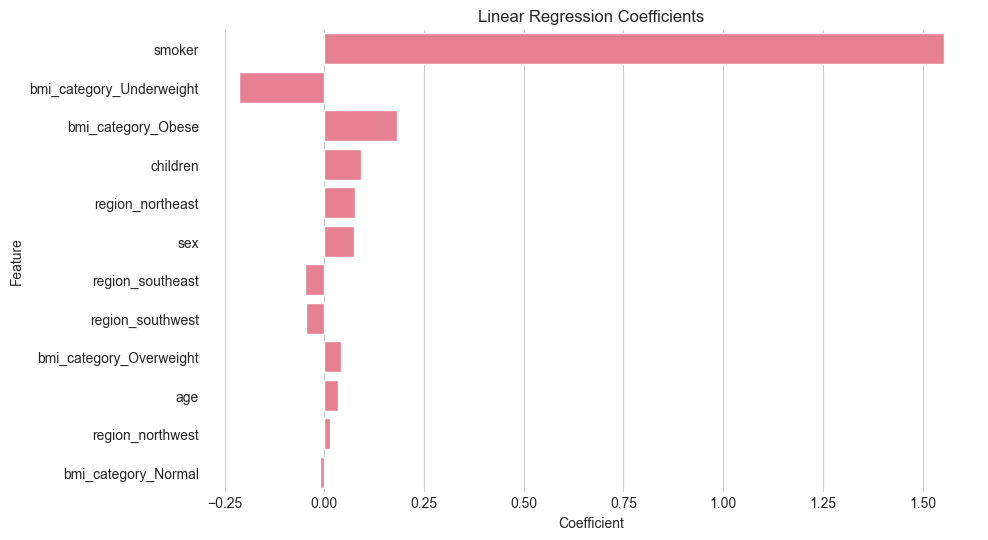

In [240]:
coefficients = pd.DataFrame({'Feature': x_train.columns, 'Coefficient': lr.coef_})
coefficients = coefficients.sort_values(by='Coefficient', key=abs, ascending=False)
print(coefficients)

sns.barplot(data=coefficients, x='Coefficient', y='Feature')
plt.title("Linear Regression Coefficients")
plt.show()

In [241]:
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_log_train)
ridge_pred = ridge.predict(x_test)
print("Ridge R^2:", r2_score(y_log_test, ridge_pred))

lasso = Lasso(alpha=0.1)
lasso.fit(x_train, y_log_train)
lasso_pred = lasso.predict(x_test)
print("Lasso R^2:", r2_score(y_log_test, lasso_pred))

Ridge R^2: 0.8030543465443695
Lasso R^2: 0.7096210033229224
